# Iris Species Classification: Train, Validation, and Test Sets

This notebook demonstrates an end-to-end Machine Learning pipeline for **Iris Species Classification** using CSV data processing:
1. **CSV Data Processing & EDA**: Reading `iris.csv` using Pandas, checking data info, missing values, and summary stats.
2. **Feature & Target Encoding**: Label encoding species target variables into numerical representations.
3. **Train, Validation, and Test Split**: Partitioning dataset into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets.
4. **Feature Scaling**: Standardizing input features using `StandardScaler` without data leakage.
5. **Model Selection & Tuning**: Evaluating multiple algorithms on the Validation Set.
6. **Final Evaluation**: Testing the final model on the unseen Test Set using Confusion Matrix and Classification Report.

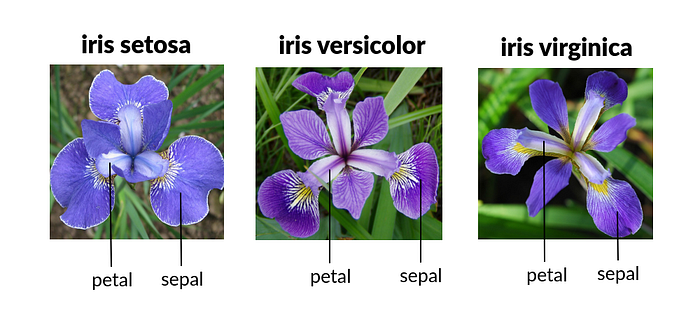

In [2]:
! pip install seaborn

In [3]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All required ML libraries imported successfully!")

All required ML libraries imported successfully!


---
## Step 1: Processing CSV Data & Exploratory Data Analysis (EDA)

We load the local `iris.csv` dataset and perform initial data exploration.

In [4]:
# 1. Load dataset from CSV file
df = pd.read_csv('iris.csv')

# 2. Display shape and first 5 rows
print(f"Dataset Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
print()
print("First 5 rows of CSV:")
print(df.head())

# 3. Check data types and missing values
print()
print("Dataset Info:")
print(df.info())

print()
print("Missing Values Check:")
print(df.isnull().sum())

# 4. Class Distribution
print()
print("Target Class Distribution:")
print(df['species'].value_counts())

Dataset Shape: (150, 5) (Rows: 150, Columns: 5)

First 5 rows of CSV:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values Check:
sepal_length    0
sepal_width     0
petal_leng

In [5]:
# Summary statistics for numerical columns
print("Numerical Feature Statistics:")
df.describe()

Numerical Feature Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


---
## Step 2: Feature & Target Preparation

Separate features ($X$) from target labels ($y$) and encode species names to integer values.

In [6]:
# 1. Features X and Target y
X = df.drop(columns=['species'])
y = df['species']

# 2. Encode categorical species to integers (0: setosa, 1: versicolor, 2: virginica)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Species Label Encoding Mapping:")
for index, label in enumerate(encoder.classes_):
    print(f"  Class {index} -> {label}")

Species Label Encoding Mapping:
  Class 0 -> setosa
  Class 1 -> versicolor
  Class 2 -> virginica


In [7]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [9]:
y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

---
## Step 3: Train, Validation, and Test Split

We split the dataset into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets using stratified sampling.

In [10]:
# Stage 1: Split full dataset into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# Stage 2: Split Temp (30%) into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

total_samples = len(df)
print("=== Dataset Split Overview ===")
print(f"  Training Set   : {X_train.shape[0]} samples ({X_train.shape[0]/total_samples*100:.1f}%)")
print(f"  Validation Set : {X_val.shape[0]} samples ({X_val.shape[0]/total_samples*100:.1f}%)")
print(f"  Test Set       : {X_test.shape[0]} samples ({X_test.shape[0]/total_samples*100:.1f}%)")

=== Dataset Split Overview ===
  Training Set   : 105 samples (70.0%)
  Validation Set : 22 samples (14.7%)
  Test Set       : 23 samples (15.3%)


---
## Step 4: Feature Scaling (Standardization)

Standardize features with zero mean and unit variance using `StandardScaler`.

In [11]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using training parameters
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed successfully!")

Feature standardization completed successfully!


In [12]:
X_train_scaled

array([[-0.90045861, -1.22024754, -0.4419858 , -0.13661044],
       [ 0.38036614, -1.87955796,  0.40282929,  0.38029394],
       [-0.90045861,  1.63676428, -1.2868009 , -1.17041921],
       [ 1.07899781,  0.31814344,  1.19132338,  1.41410271],
       [-0.20182693, -0.56093712,  0.17754527,  0.12184175],
       [ 0.9625592 , -0.12139684,  0.79707634,  1.41410271],
       [-1.13333583,  0.0983733 , -1.2868009 , -1.4288714 ],
       [-0.90045861,  1.63676428, -1.23047989, -1.29964531],
       [-1.7155289 , -0.34116698, -1.3431219 , -1.29964531],
       [ 1.42831365, -0.12139684,  1.19132338,  1.15565051],
       [ 0.72968197,  0.31814344,  0.74075533,  1.02642442],
       [-1.13333583, -0.12139684, -1.3431219 , -1.29964531],
       [-1.01689722, -0.12139684, -1.23047989, -1.29964531],
       [ 0.14748891, -0.34116698,  0.40282929,  0.38029394],
       [-0.43470415, -1.44001768,  0.00858225, -0.13661044],
       [ 1.54475226,  0.31814344,  1.24764439,  0.76797223],
       [-1.01689722,  0.

In [13]:
X_val_scaled

array([[ 0.9625592 , -0.12139684,  0.68443432,  0.63874613],
       [ 0.61324336, -0.78070726,  0.85339734,  0.89719832],
       [-0.31826554, -1.22024754,  0.06490325, -0.13661044],
       [ 0.49680475, -0.56093712,  0.74075533,  0.38029394],
       [ 1.19543642,  0.0983733 ,  0.74075533,  1.41410271],
       [-0.55114277, -0.12139684,  0.40282929,  0.38029394],
       [-0.55114277,  0.75768372, -1.17415888, -1.29964531],
       [-1.48265167,  1.197224  , -1.56840593, -1.29964531],
       [-0.90045861,  0.53791358, -1.17415888, -0.91196702],
       [-1.01689722,  0.97745386, -1.23047989, -0.78274092],
       [-1.13333583, -1.22024754,  0.40282929,  0.63874613],
       [ 0.84612059, -0.12139684,  0.34650829,  0.25106784],
       [ 0.9625592 , -1.22024754,  1.13500238,  0.76797223],
       [-0.08538832,  2.07630456, -1.45576392, -1.29964531],
       [-1.7155289 ,  0.31814344, -1.39944291, -1.29964531],
       [-0.43470415, -1.65978782,  0.12122426,  0.12184175],
       [ 1.66119088, -0.

In [14]:
X_test_scaled

array([[-0.20182693,  1.63676428, -1.17415888, -1.17041921],
       [-1.7155289 , -0.12139684, -1.39944291, -1.29964531],
       [ 0.26392752, -1.0004774 ,  1.02236036,  0.25106784],
       [-1.13333583, -1.44001768, -0.27302278, -0.26583654],
       [ 0.26392752, -0.12139684,  0.62811332,  0.76797223],
       [ 0.9625592 ,  0.0983733 ,  1.02236036,  1.5433288 ],
       [ 0.38036614, -0.34116698,  0.29018728,  0.12184175],
       [ 0.38036614,  0.75768372,  0.90971835,  1.41410271],
       [-1.01689722,  0.75768372, -1.2868009 , -1.29964531],
       [ 0.61324336,  0.31814344,  0.40282929,  0.38029394],
       [ 0.84612059, -0.34116698,  0.4591503 ,  0.12184175],
       [-1.36621306,  0.31814344, -1.39944291, -1.29964531],
       [ 0.26392752, -0.34116698,  0.51547131,  0.25106784],
       [ 0.61324336, -0.56093712,  1.02236036,  1.28487661],
       [ 0.49680475,  0.53791358,  0.51547131,  0.50952003],
       [ 0.14748891, -0.12139684,  0.57179231,  0.76797223],
       [-1.01689722,  0.

---
## Step 5: Model Training & Validation Set Evaluation

We train 4 classifiers on the Training Set and compare accuracy on the **Validation Set**.

In [15]:
# Dictionary of classification models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

val_results = {}

print("=== Validation Set Model Evaluation ===")
for name, model in models.items():
    # Train on Training Data
    model.fit(X_train_scaled, y_train)
    
    # Predict on Validation Data
    val_preds = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, val_preds)
    val_results[name] = acc
    print(f"  {name:25s} -> Validation Accuracy: {acc * 100:.2f}%")

=== Validation Set Model Evaluation ===
  Logistic Regression       -> Validation Accuracy: 86.36%
  K-Nearest Neighbors       -> Validation Accuracy: 90.91%
  Support Vector Machine    -> Validation Accuracy: 86.36%
  Decision Tree             -> Validation Accuracy: 90.91%


---
## Step 6: Final Model Evaluation on Unseen Test Set

Evaluate the best performing model on the **Test Set** to verify generalization capability.

In [16]:
# Select best model (Logistic Regression)
best_model = LogisticRegression(random_state=42)
best_model.fit(X_train_scaled, y_train)

# Predict on unseen Test Set
test_preds = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)

print(f"=== Final Unseen Test Set Accuracy: {test_acc * 100:.2f}% ===")
print()
# Detailed Classification Metrics
print("Classification Report (Test Set):")
print(classification_report(y_test, test_preds, target_names=encoder.classes_))

=== Final Unseen Test Set Accuracy: 95.65% ===

Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.89      1.00      0.94         8
   virginica       1.00      0.88      0.93         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



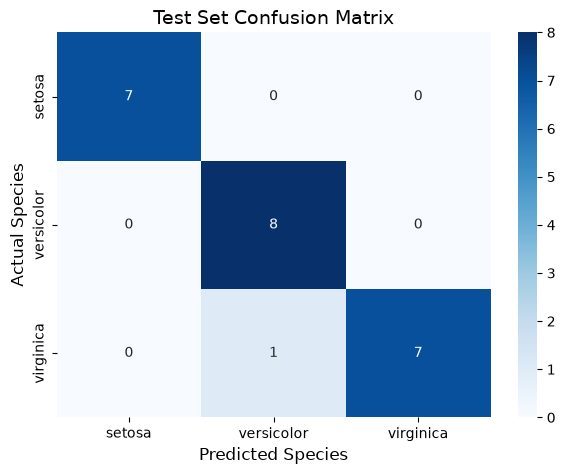

In [17]:
# Confusion Matrix Visualization for Test Set
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('Actual Species', fontsize=12)
plt.show()

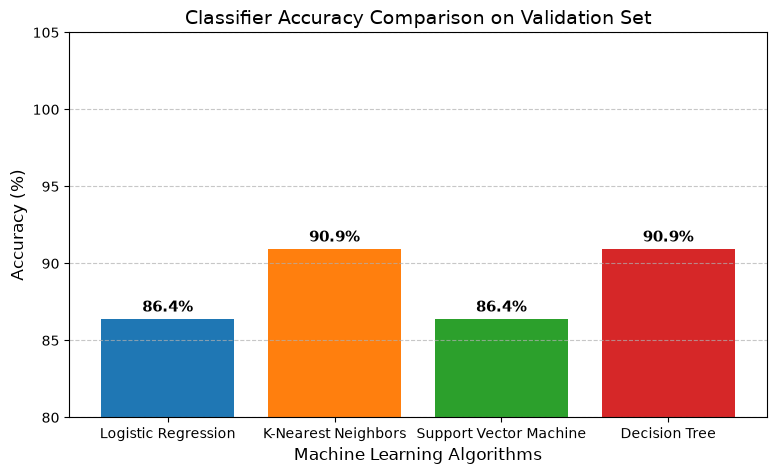

In [18]:
# Bar chart comparison of Validation Accuracies
plt.figure(figsize=(9, 5))
model_names = list(val_results.keys())
accuracies = [val_results[m] * 100 for m in model_names]

bars = plt.bar(model_names, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Classifier Accuracy Comparison on Validation Set', fontsize=14)
plt.xlabel('Machine Learning Algorithms', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(80, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

#### Now try this out and get a certification : https://www.kaggle.com/learn/intro-to-machine-learning